In [1]:
import jax
import jax.numpy as jnp
import optax
from flax.training import train_state
from flax import linen as nn
from jax.scipy.integrate import trapezoid
from tqdm import tqdm

(5, 5)
(5, 5)
[[0.   1.25 2.5  3.75 5.  ]
 [0.   1.25 2.5  3.75 5.  ]
 [0.   1.25 2.5  3.75 5.  ]
 [0.   1.25 2.5  3.75 5.  ]
 [0.   1.25 2.5  3.75 5.  ]]
[0.   1.25 2.5  3.75 5.   0.   1.25 2.5  3.75 5.   0.   1.25 2.5  3.75
 5.   0.   1.25 2.5  3.75 5.   0.   1.25 2.5  3.75 5.  ]
[-5.  -5.  -5.  -5.  -5.  -2.5 -2.5 -2.5 -2.5 -2.5  0.   0.   0.   0.
  0.   2.5  2.5  2.5  2.5  2.5  5.   5.   5.   5.   5. ]
[0.   1.25 2.5  3.75 5.   0.   1.25 2.5  3.75 5.   0.   1.25 2.5  3.75
 5.   0.   1.25 2.5  3.75 5.   0.   1.25 2.5  3.75 5.  ]
(5, 5)


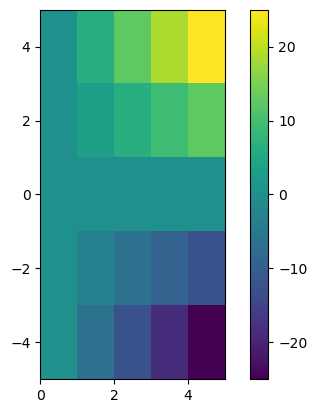

In [2]:
NPOINTSX = 5
NPOINTSY = 5
X_min, X_max = 0, 5.0
Y_min, Y_max = -5.0, 5.0
x = jnp.linspace(X_min, X_max, NPOINTSX)
y = jnp.linspace(Y_min, Y_max, NPOINTSY)

X, Y = jnp.meshgrid(x, y)
coords = jnp.stack([X.ravel(), Y.ravel()], axis=-1)

print(X.shape)
print(Y.shape)

print(X)
print(X.ravel())
print(Y.ravel())

print(coords[:,0])

X_reconstructed, Y_reconstructed = coords[:,0].reshape(NPOINTSY, NPOINTSX), coords[:,1].reshape(NPOINTSY, NPOINTSX)
print(X_reconstructed.shape)

Nx = X.shape[-1]
Ny = Y.shape[0]

assert Nx == NPOINTSX, "Shape mismatch: expected {}, got {}".format(NPOINTSX, Nx)
assert Ny == NPOINTSY, "Shape mismatch: expected {}, got {}".format(NPOINTSY, Ny)

assert coords.shape == (NPOINTSX*NPOINTSY, 2)

def f(x):
    return x[:,0]*x[:,1]

z = f(coords)

assert z.shape == (NPOINTSX*NPOINTSY, ), "Shape mismatch: expected (NPOINTSX*NPOINTSY,), got {}".format(z.shape)


import matplotlib.pyplot as plt
import numpy as np

X_arr = np.array(X)
Y_arr = np.array(Y)
z_arr = np.array(z)

plt.imshow(z_arr.reshape(Ny, Nx), extent=(X_min, X_max, Y_min, Y_max), origin='lower', cmap='viridis')
plt.colorbar()


In [3]:
# Define a simple MLP using Flax Linen
class MLP(nn.Module):
    architecture: list
    hidden_activation: callable = nn.tanh

    @nn.compact
    def __call__(self, x):
        for i in range(len(self.architecture) - 1):
            x = nn.Dense(features=self.architecture[i + 1])(x)
            if i < len(self.architecture) - 2:
                x = self.hidden_activation(x)
        return x

In [4]:
def trapz_2d_from_flat(fvals_flat, xs, ys):
    Nx = xs.size
    Ny = ys.size
    Z = fvals_flat.reshape(Ny, Nx)  # IMPORTANT: order = row-major (y,x)
    Fx = jnp.trapezoid(Z, xs, axis=1)   # integrate over x → shape (Ny,)
    return jnp.trapezoid(Fx, ys)

In [5]:
X, Y = jnp.meshgrid(jnp.linspace(0, 1, 1000), jnp.linspace(0, 1, 10))
Z = X*Y + 1

print("shape of Z:", Z.shape)
print("shape of ravel z:", Z.ravel().shape)
print("shape of X[0,:]:", X[0,:].shape)
print("shape of X:", X.shape)

integral_2d = trapz_2d_from_flat(Z.ravel(), X[0,:], Y[:,0])
print("2D integral result:", integral_2d)

shape of Z: (10, 1000)
shape of ravel z: (10000,)
shape of X[0,:]: (1000,)
shape of X: (10, 1000)
2D integral result: 1.25


In [6]:
def laplace(func, x):
    """Compute the Laplace operator of the model output with respect to inputs."""
    grad_fn = jax.grad(func)
    d2_dx2 = 0
    for i in range(x.shape[1]):
        d2_dx2 += jax.vmap(jax.grad(lambda xi: grad_fn(xi)[i]))(x)[:, i]
    return d2_dx2

# compute kinetic term with AD (correct)
def local_energy_batch(params, xs, model_apply):
    # xs: (batch, 1) or (batch,)
    # psi(x) -> scalar
    def psi_fn(x):
        # ensure input has shape (1,) as model expects last-dim features
        x = jnp.atleast_1d(x).reshape(1, -1)  # (1, DoF)
        return model_apply(params, x).squeeze()

    # second derivative per sample via AD
    d2psi = laplace(psi_fn, xs)

    psi_vals = jax.vmap(lambda x: psi_fn(x))(xs)  # shape (batch,)

    # avoid division by zero / small psi
    psi_safe = psi_vals + 1e-12

    kinetic = -0.5 * (d2psi / psi_safe)  # shape (batch,)
    # potential = 0.5 * (xs_flat**2)  # shape (batch,)
    potential = 0.5 * jnp.sum(xs**2, axis=1)
    return (kinetic + potential).reshape(-1, 1)  # keep your (batch,1) convention

def log_psi(x, params, model_apply):
    psi = model_apply(params, x)
    return jnp.log(jnp.abs(psi) + 1e-8)  # Add small constant to avoid log(0)

grad_log_psi = jax.grad(lambda params, x, model_apply: log_psi(x, params, model_apply), argnums=0) # CAREFUL WITH THE DERIVATIVES: WE WANT THE GRADIENT WRT THE PARAMETERS, so we turn the order of the p and x

def log_psi_and_grad(params, x, model_apply):
    psi = model_apply(params, x)
    log_psi_val = jnp.log(jnp.abs(psi) + 1e-8)
    grad_log_psi_val = grad_log_psi(params, x, model_apply)
    return log_psi_val, grad_log_psi_val

def energy_fn(params, batch, model_apply, unstacked_points):
    psi = jax.vmap(lambda x: model_apply(params, x))(batch)
    psi_squared = jnp.abs(psi)**2
    local_energy_per_point = local_energy_batch(params, batch, model_apply)

    energy_integrand = psi_squared * local_energy_per_point

    X = unstacked_points[0]
    Y = unstacked_points[1]

    Nx = X.shape[-1]
    Ny = Y.shape[0]
    energy_integrand_reshaped = energy_integrand.reshape(Ny, Nx)
    psi_squared_reshaped = psi_squared.reshape(Ny, Nx)

    # 2d integral via trapezoidal rule
    norm = trapz_2d_from_flat(psi_squared_reshaped.ravel(), unstacked_points[0][0,:], unstacked_points[1][:,0])
    integral = trapz_2d_from_flat(energy_integrand_reshaped.ravel(), unstacked_points[0][0,:], unstacked_points[1][:,0])
    return integral / norm

def loss_and_grads(params, batch, model_apply, unstacked_points=None):
    E = energy_fn(params, batch, model_apply, unstacked_points)
    grad_E = jax.grad(energy_fn, argnums=0)(params, batch, model_apply, unstacked_points)
    return E, grad_E

@jax.jit
def train_step(state, batch, unstacked_points=None):
    E, grads = loss_and_grads(state.params, batch, state.apply_fn, unstacked_points=unstacked_points)
    new_state = state.apply_gradients(grads=grads)
    return new_state, E

def train(n_steps, init_params, model_apply, optimizer, points, unstacked_points=None):

    state = train_state.TrainState.create(
        apply_fn=model_apply,
        params=init_params,
        tx=optimizer
    )

    energy_history = []
    batch = points

    for step in tqdm(range(n_steps)):
        # batch = sampler(state.params, state.apply_fn)
        state, energy = train_step(state, batch, unstacked_points=unstacked_points)
        energy_history.append(energy)

    return state.params, energy_history

In [7]:
BATCH_SIZE = 50

x = jnp.linspace(-5,5,BATCH_SIZE)
y = jnp.linspace(-5,5,BATCH_SIZE)

points = jnp.stack([x,y], axis=1)
print(points.shape)

input_shape = (BATCH_SIZE, 2)

X, Y = jnp.meshgrid(x,y)
coords = jnp.stack([X.ravel(), Y.ravel()]).transpose()

print(coords.shape)

rng_key = jax.random.PRNGKey(0)

model = MLP(architecture=[2,30,1])
params = model.init(rng_key, jnp.ones(input_shape))
params_fin, energy = train(4000, params, model.apply, optax.adam(1e-3), points = coords, unstacked_points = (X, Y))


(50, 2)
(2500, 2)


100%|██████████| 4000/4000 [00:05<00:00, 744.54it/s] 


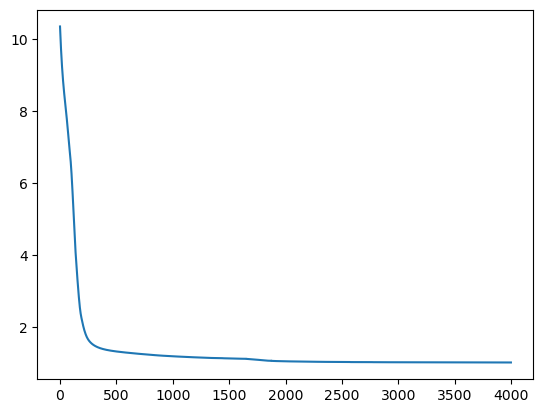

Final energy: 1.0218987


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 302, in dispatch_control
    await self.process_control(msg)
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 308, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/pfargas/software/anaconda3/envs/jax/lib/python3.13/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home

In [ ]:
import matplotlib.pyplot as plt
plt.plot(energy)
plt.show()
print("Final energy:", energy[-1])